In [1]:
import geopandas as gpd
from pathlib import Path

In [6]:
# local authority district boundaries
region_geojson_path = Path("../airbyte/utils/os-ngd/Regions_December_2024_Boundaries_EN_BGC_-3699623982958172124.geojson")
print(region_geojson_path.exists(), region_geojson_path.resolve())

True /home/ubuntu/IRIS-data-cleanser/airbyte/utils/os-ngd/Regions_December_2024_Boundaries_EN_BGC_-3699623982958172124.geojson


In [ ]:
# import the data
region_gdf = gpd.read_file(region_geojson_path)

print("region_gdf Shape:", region_gdf.shape)
print("Coordinate Reference System", region_gdf.crs)

region_gdf Shape: (9, 9)
Coordinate Reference System EPSG:4326


In [8]:
# first few rows
region_gdf.head()

,FID,RGN24CD,RGN24NM,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry
0,1,E12000001,North East,417315,600357,-1.72887,55.29702,12201951-50af-4e67-bd5e-bc5e19b04b9b,"MULTIPOLYGON (((-1.22289 54.62587, -1.225 54.6..."
1,2,E12000002,North West,350014,506279,-2.77239,54.44944,0a07bcad-79b5-41b4-8e47-7ab3831f733d,"MULTIPOLYGON (((-3.08326 53.2559, -3.08309 53...."
2,3,E12000003,Yorkshire and The Humber,446902,448736,-1.28714,53.93265,1e65ebb6-acff-4cfd-b6e5-5e3dca036baa,"MULTIPOLYGON (((-0.55549 53.69052, -0.54641 53..."
3,4,E12000004,East Midlands,477658,322635,-0.84971,52.79572,ec7a03af-0d6a-41a5-90f4-6a93e9b22d34,"MULTIPOLYGON (((0.26878 52.81586, 0.26747 52.8..."
4,5,E12000005,West Midlands,386293,295477,-2.20360,52.55697,42e5f029-56ae-4947-ac95-ee7f44a564cc,"POLYGON ((-1.95083 53.21196, -1.94891 53.21171..."


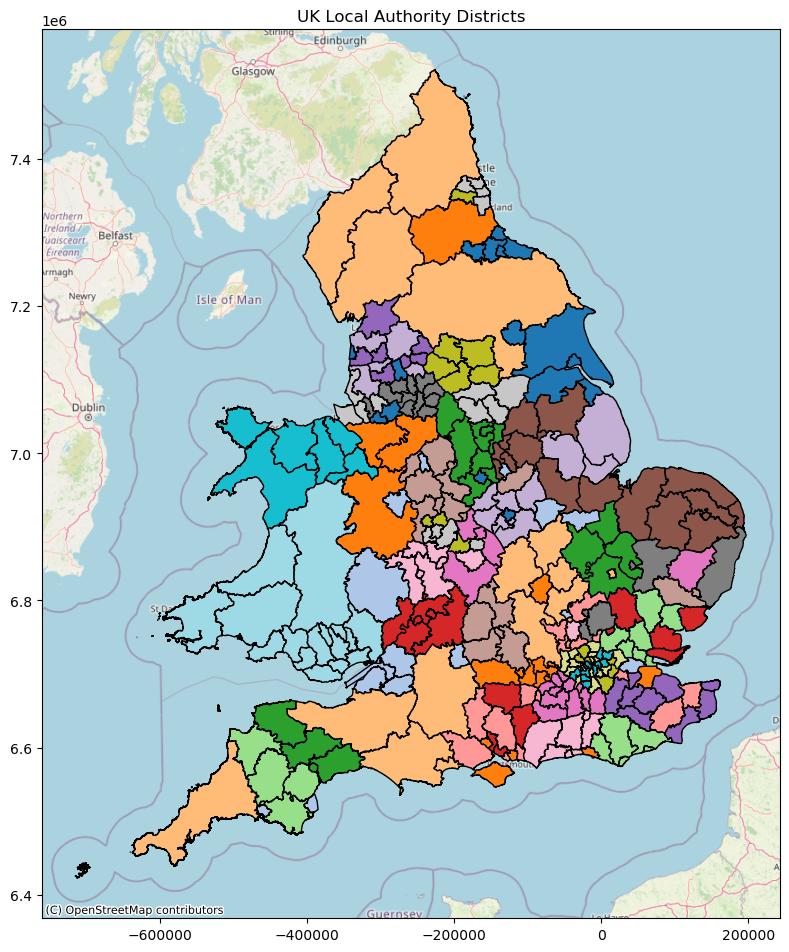

In [ ]:
import matplotlib.pyplot as plt
import contextily as ctx

r_web = region_gdf.to_crs(epsg="3857")

ax = r_web.plot(
    figsize=(8, 10),
    column="LAD24CD",
    edgecolor="black",
    cmap="tab20"
)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title("UK Local Authority Districts")

plt.tight_layout()
plt.show()

In [21]:
# get LAD codes
export_path = Path("../airbyte/infra/spatial/ew_lad.csv")
ew["LAD24CD"].to_csv(export_path)